In [1]:
import torch
torch.set_printoptions(precision=3, sci_mode=False)

%load_ext autoreload
%autoreload 2

In [2]:
from icl.utils.unified_interface import unified_train

task_name = "latent"
for k in range(-1, 14):
    results = unified_train(task_name, k=k)

2026-03-02 02:22:32 - icl.latent_markov.analysis.variance - INFO - Computing non-padded task variance for latent exp: train_7f910b8279bc154dd0273c4b3a0a7191
2026-03-02 02:22:32 - icl.latent_markov.analysis.variance - INFO - Layers: range(2, 6), B: 64, n_tasks: 3 (k_minor=0)
2026-03-02 02:22:33 - icl.latent_markov.analysis.variance - INFO - Hiddens shape: torch.Size([4, 3, 191, 64, 128]). Computing task variance...
2026-03-02 02:22:33 - icl.latent_markov.analysis.variance - INFO - Computed variance for 4 layers


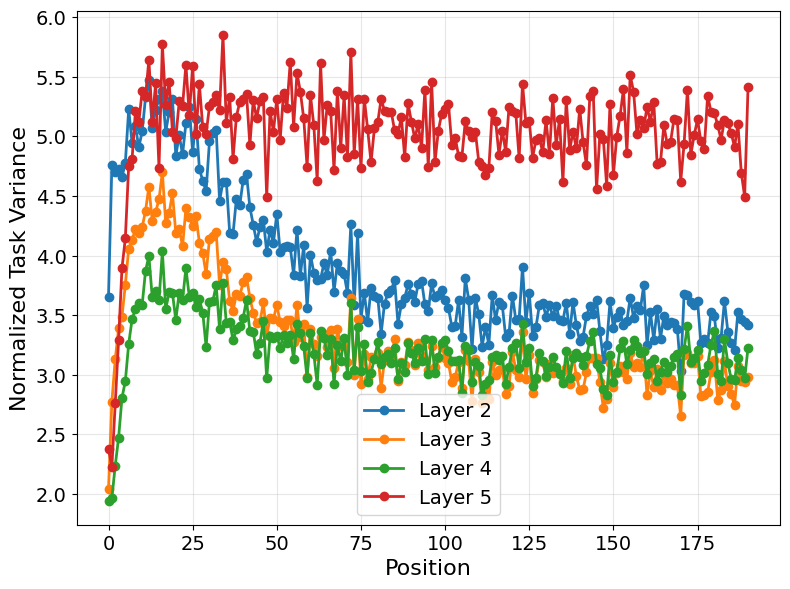

In [3]:
from icl.latent_markov.analysis import plot_task_variance
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", -1)
results = plot_task_variance(
    exp_name,
    layers=range(2, 6),
    batch_size=64,
    n_minor=0,       # capped at sampler's actual count
    verbose=True,
    log_x=False,
)

2026-03-02 02:23:58 - icl.latent_markov.analysis.variance - INFO - Computing non-padded token-conditioned hiddens for latent exp: train_7f910b8279bc154dd0273c4b3a0a7191
2026-03-02 02:23:58 - icl.latent_markov.analysis.variance - INFO - Layers: range(2, 6), Batch size: 64, n_tasks: 3
2026-03-02 02:26:36 - icl.latent_markov.analysis.variance - INFO - Computed hiddens shape: torch.Size([4, 191, 8, 3, 64, 128])
2026-03-02 02:26:36 - icl.latent_markov.analysis.variance - INFO - Token info - positions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 12

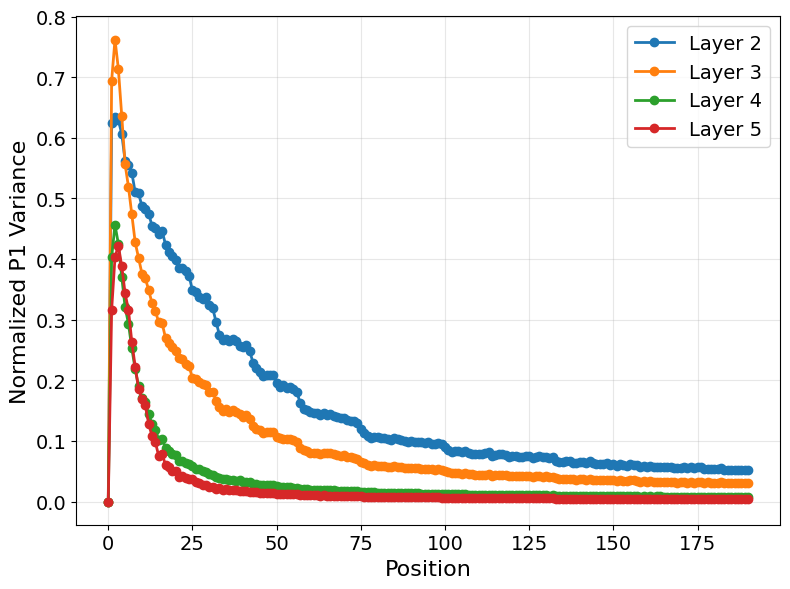

In [4]:
from icl.latent_markov.analysis import plot_p1_variance
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", -1)
results = plot_p1_variance(
    exp_name,
    layers=range(2, 6),
    batch_size=64,
    n_minor=0,       # capped at sampler's actual count
    verbose=True,
    log_x=False,
)

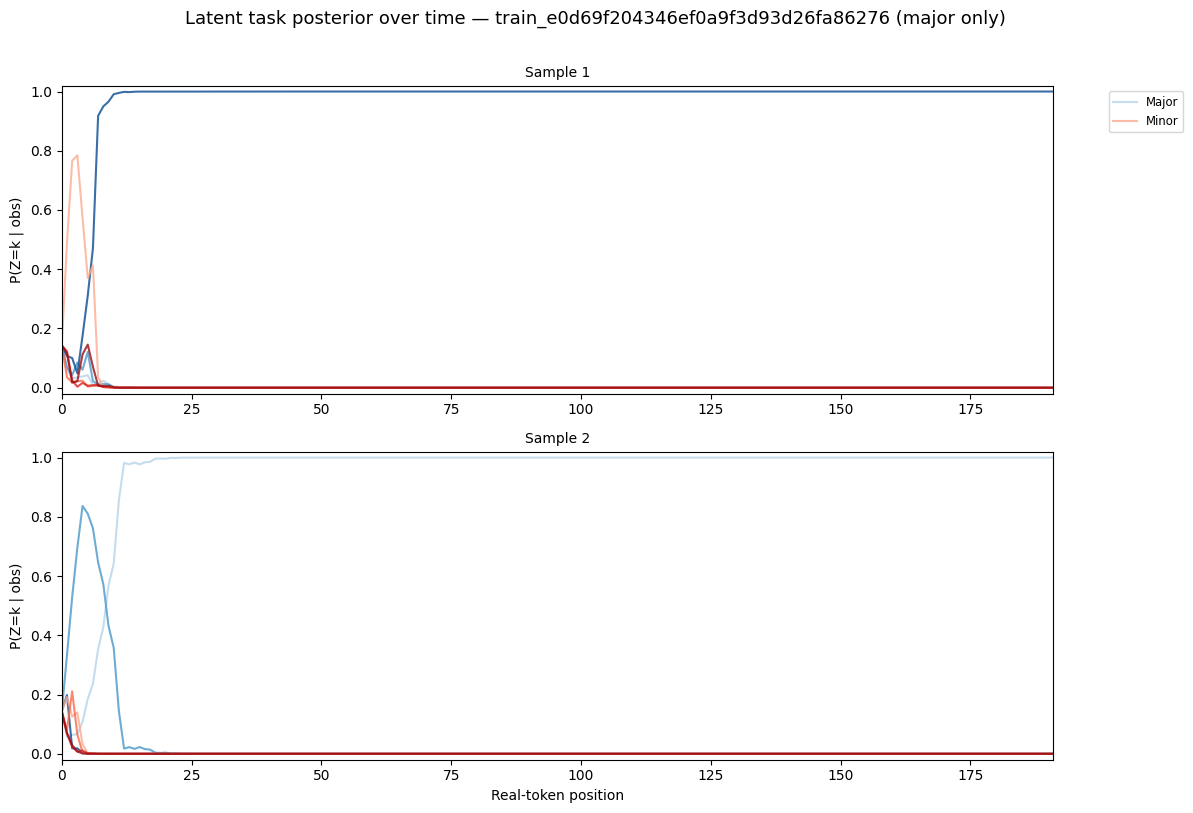

In [7]:
from icl.latent_markov.analysis.posterior import plot_latent_task_posterior

exp_name = get_exp_name("latent", k=2)
info = plot_latent_task_posterior(exp_name, n_plots=2, major_only=True,)

In [9]:
from icl.latent_markov.analysis.probes import train_linear_hidden_predictor
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", -1)
res = train_linear_hidden_predictor(
    exp_name, 
    layer=3,
    sample_mode="major",
    positions=range(1, 20),
    )


=== Fit Summary (Latent non-padded, layer 3, mode='major') ===
Model                       Train R²     Val R²      Val MSE
-----------------------------------------------------------
Joint (task+tok+logit)        0.7582     0.7559     0.446905
Post+tok (no logit)           0.7415     0.7390     0.477888
Posterior only                0.3539     0.3558     1.179375
Token only                    0.4221     0.4191     1.063508
Logit only                    0.3091     0.2985     1.284206

Partial R²  posterior|rest = 0.4467    token|rest = 0.4342    logit|rest = 0.0648
F-test  posterior: F=3950.1 p=0.00e+00   token: F=1534.9 p=0.00e+00   logit: F=134.4 p=3.23e-219
Condition number: 19748918.0

  Design matrix collinearity:
    Group         dims        VIF  GVIF^(1/2p)   R² from rest
    -------------------------------------------------------
    posterior        3       1.88       1.1114         0.4694
    token            8       2.06       1.0463         0.5156
    logit            8  

2026-03-02 02:54:15 - icl.latent_markov.analysis.probes - INFO - [sweep] running layer 0 ...
2026-03-02 02:54:39 - icl.latent_markov.analysis.probes - INFO - [sweep] running layer 1 ...
2026-03-02 02:55:02 - icl.latent_markov.analysis.probes - INFO - [sweep] running layer 2 ...
2026-03-02 02:55:26 - icl.latent_markov.analysis.probes - INFO - [sweep] running layer 3 ...
2026-03-02 02:55:50 - icl.latent_markov.analysis.probes - INFO - [sweep] running layer 4 ...
2026-03-02 02:56:14 - icl.latent_markov.analysis.probes - INFO - [sweep] running layer 5 ...

  Design Matrix Collinearity Summary (layer-independent)
  Condition number: 1.29e+07
  Features: posterior=3  token=8  logit=8  (total=19)

  Group         dims        VIF  GVIF^(1/2p)   R² from rest
  -------------------------------------------------------
  posterior        3       1.89       1.1123         0.4718
  token            8       2.08       1.0468         0.5188
  logit            8       2.00       1.0442         0.4997

 

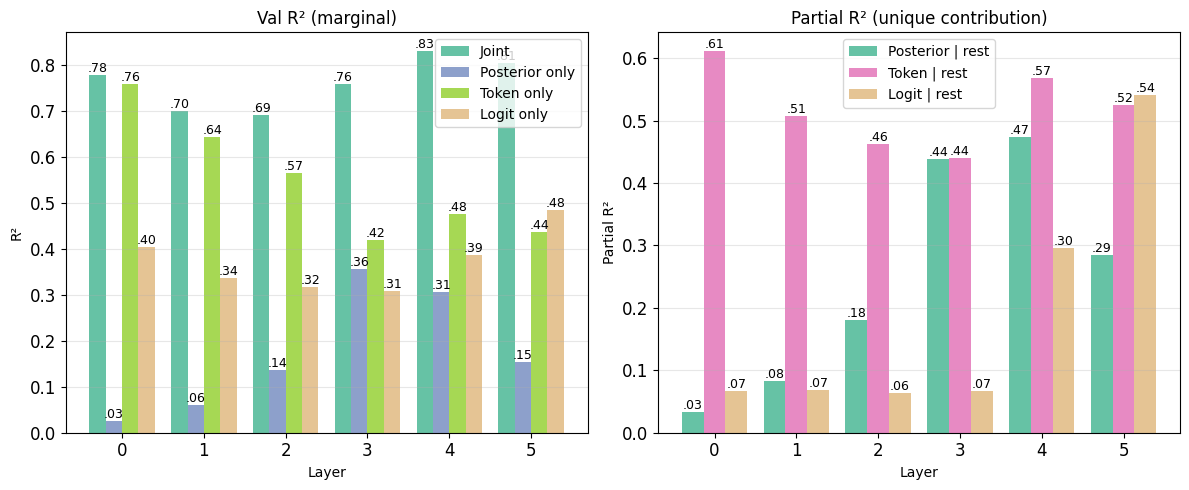

In [10]:
from icl.latent_markov.analysis import plot_val_r2_across_layers
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=-1)  # no minor tasks

fig, all_results = plot_val_r2_across_layers(
    exp_name,
    layers=[0, 1, 2, 3, 4, 5],
    B=64,
    n_samples=2**13,
    positions=range(1, 20),
    sample_mode="major",  # or "train", "minor"
)

2026-03-02 02:57:46 - icl.latent_markov.analysis.probes - INFO - [sweep] running layer 0 ...
2026-03-02 02:59:40 - icl.latent_markov.analysis.probes - INFO - [sweep] running layer 1 ...
2026-03-02 03:01:35 - icl.latent_markov.analysis.probes - INFO - [sweep] running layer 2 ...
2026-03-02 03:03:28 - icl.latent_markov.analysis.probes - INFO - [sweep] running layer 3 ...
2026-03-02 03:05:20 - icl.latent_markov.analysis.probes - INFO - [sweep] running layer 4 ...
2026-03-02 03:07:12 - icl.latent_markov.analysis.probes - INFO - [sweep] running layer 5 ...

  Design Matrix Collinearity Summary (layer-independent)
  Condition number: 2.48e+06
  Features: posterior=3  token=8  logit=8  (total=19)

  Group         dims        VIF  GVIF^(1/2p)   R² from rest
  -------------------------------------------------------
  posterior        3       1.59       1.0800         0.3698
  token            8       1.76       1.0360         0.4324
  logit            8       1.94       1.0424         0.4851

 

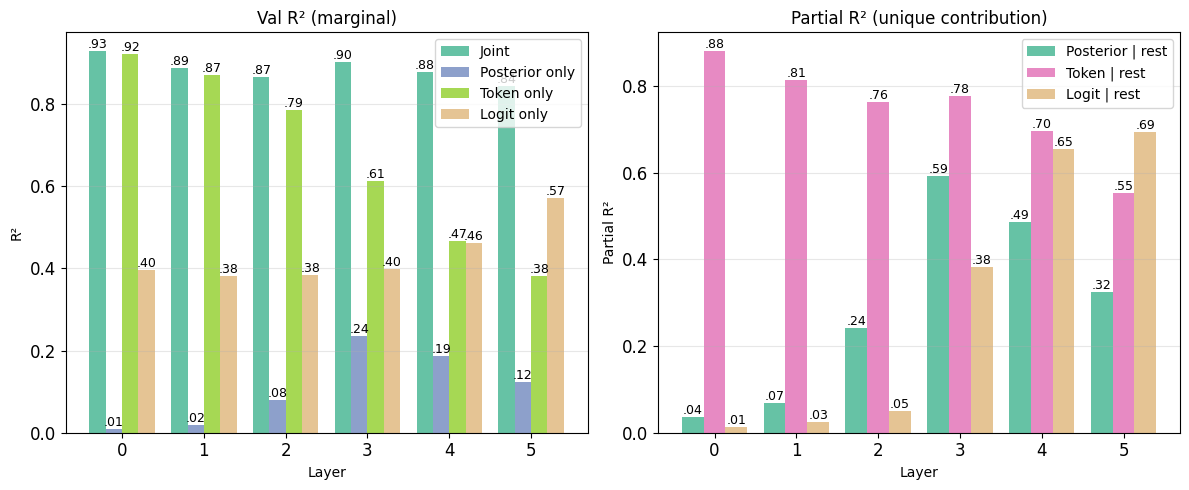

In [11]:
from icl.latent_markov.analysis import plot_val_r2_across_layers
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=2)  # no minor tasks

fig, all_results = plot_val_r2_across_layers(
    exp_name,
    layers=[0, 1, 2, 3, 4, 5],
    B=64,
    n_samples=2**13,
    positions=range(100, 180),
    sample_mode="major",  # or "train", "minor"
)

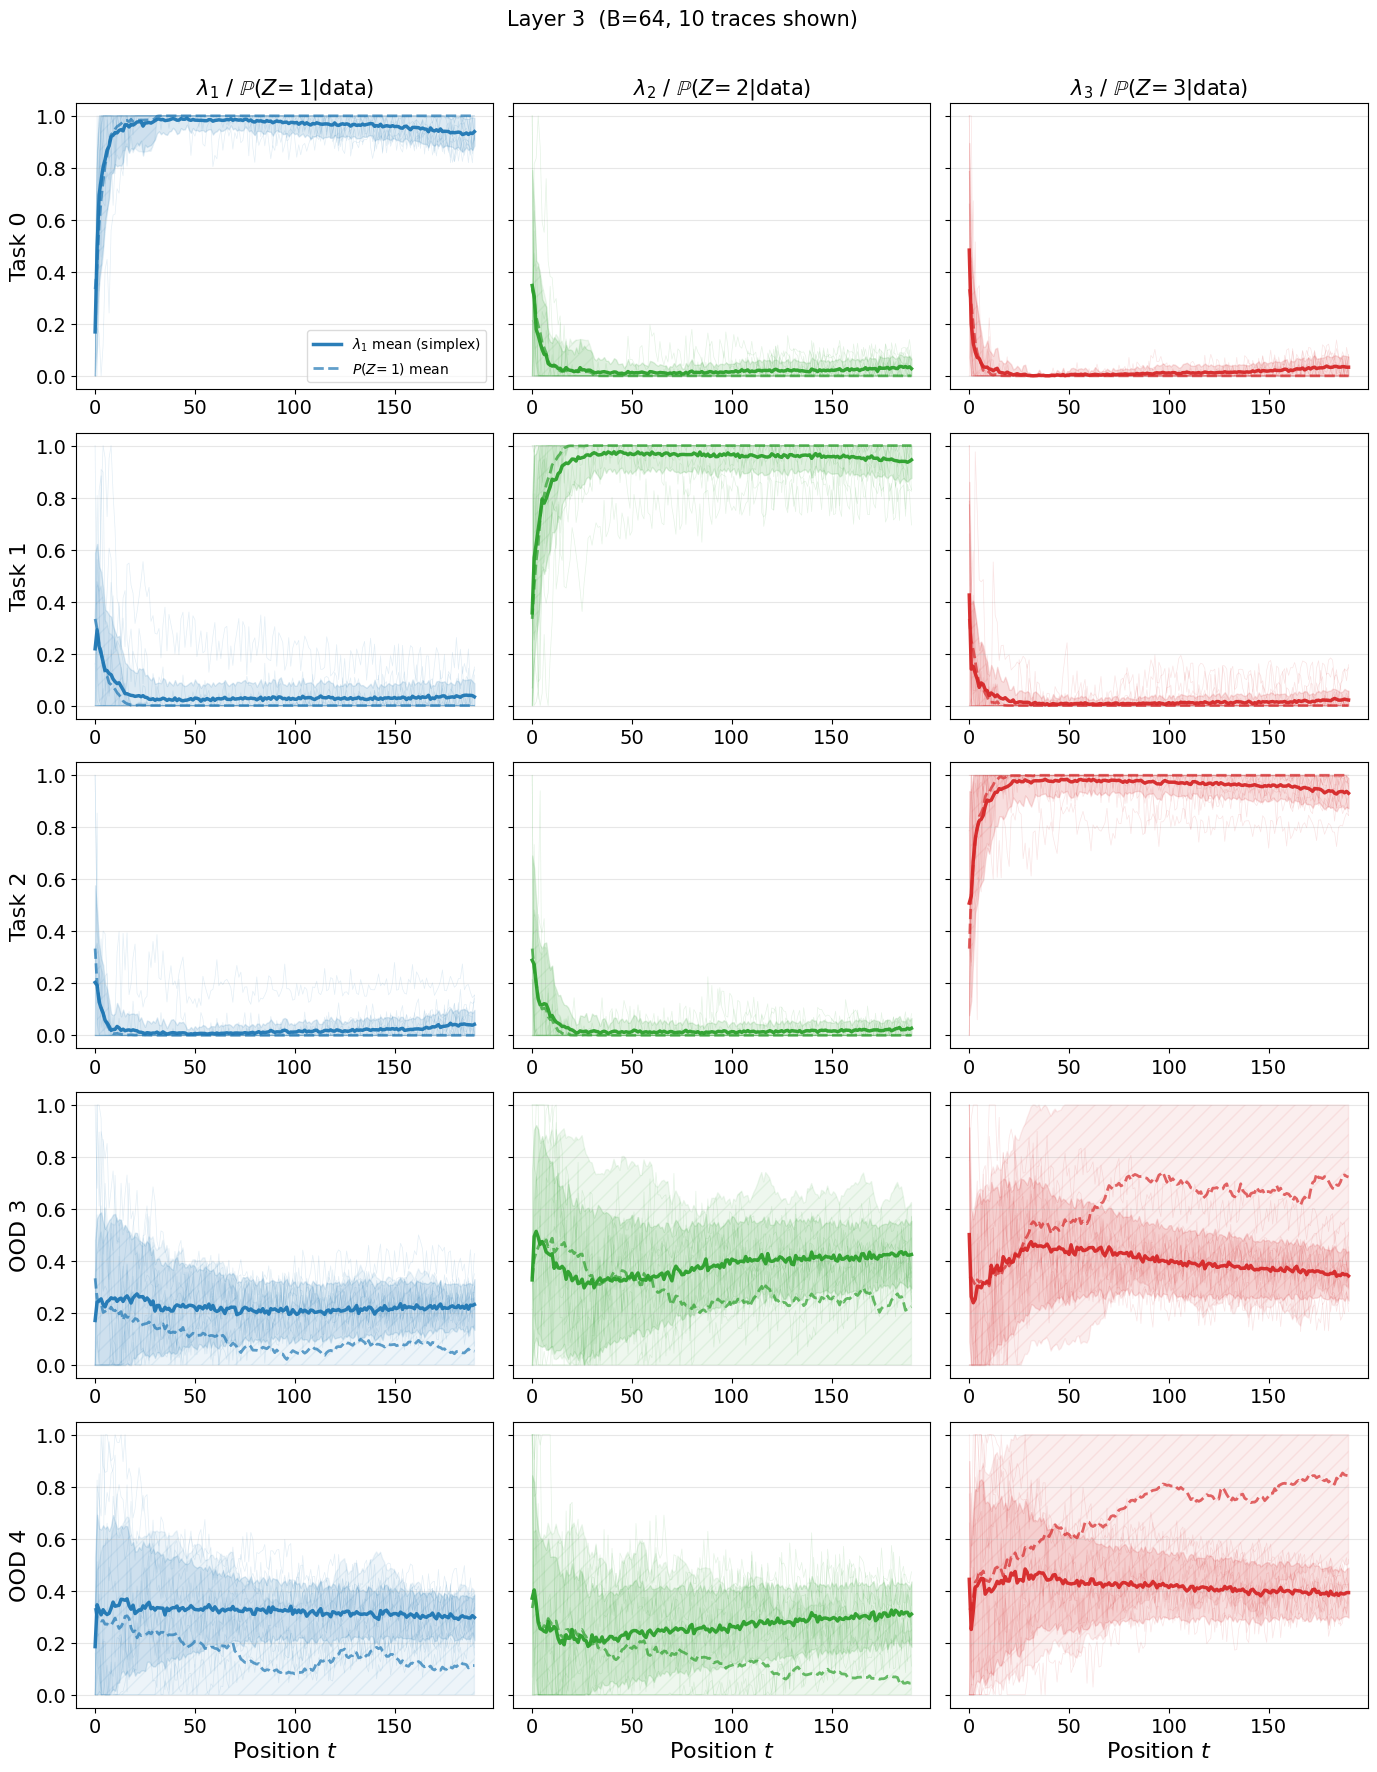

In [29]:
from icl.latent_markov.analysis import traj_post_posterior_projection_plot
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=-1)

out = traj_post_posterior_projection_plot(
    exp_name,
    layer_index=3,
    task_ids=range(5),   # major task
    B=64,
    fit_positions=list(range(1, 25)) + list(range(150, 180)),
)
# Or task_id=5 for OOD (λ vs misspecified posterior)

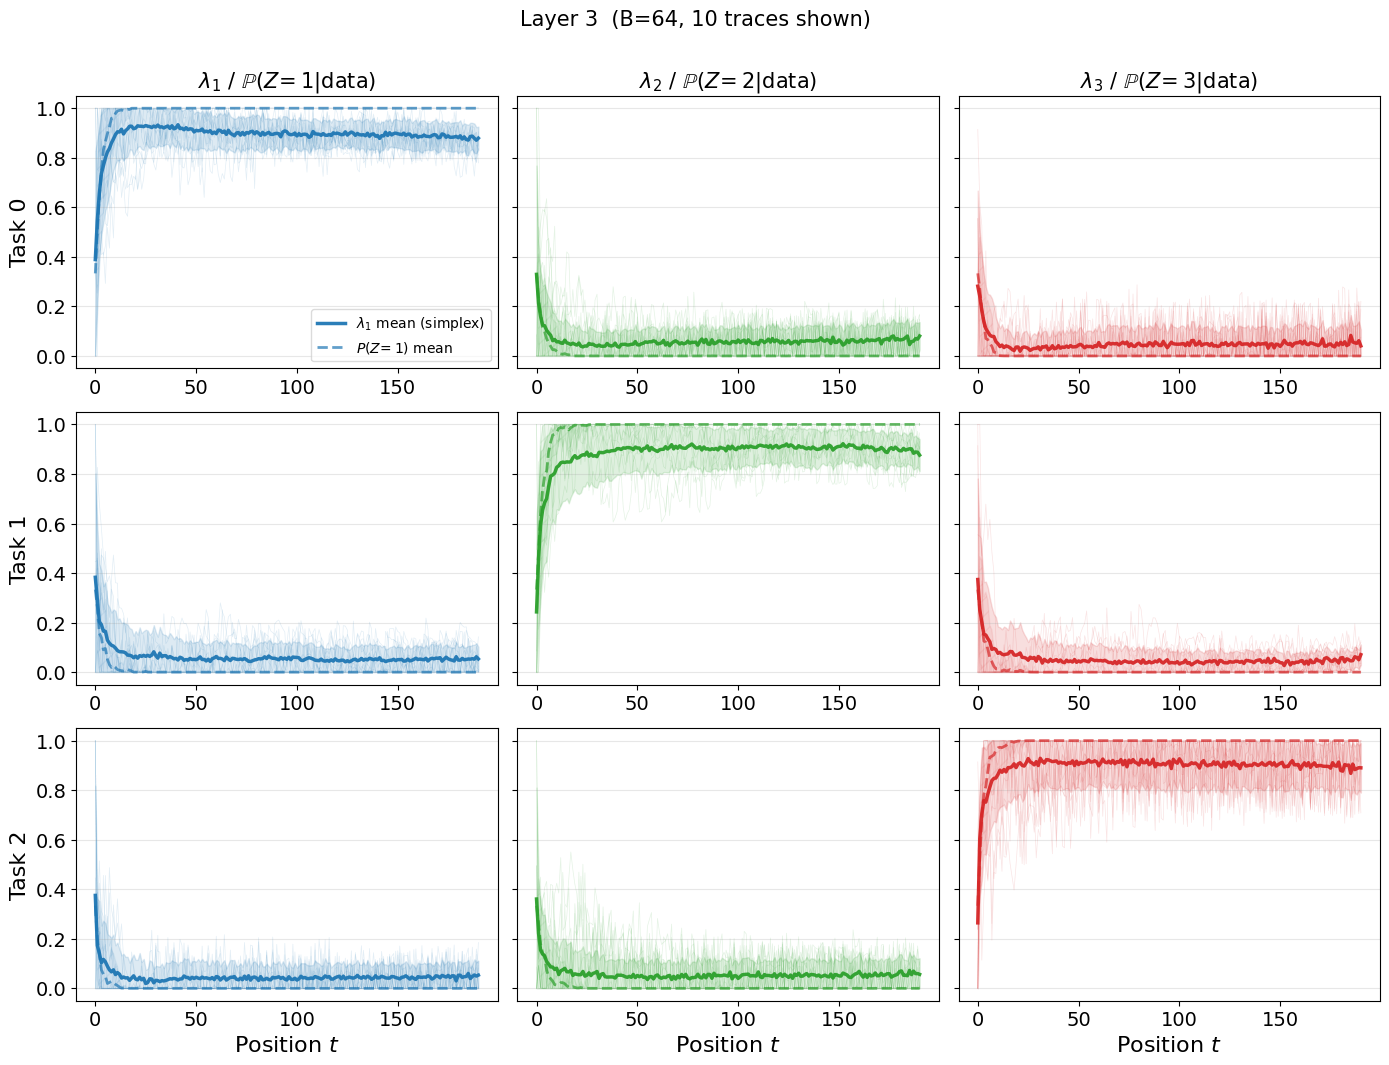

In [30]:
from icl.latent_markov.analysis import traj_post_posterior_projection_plot
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=8)

out = traj_post_posterior_projection_plot(
    exp_name,
    layer_index=3,
    task_ids=range(3),   # major task
    fit_positions=list(range(1, 25)) + list(range(150, 180)),
    B=64,
)
# Or task_id=5 for OOD (λ vs misspecified posterior)

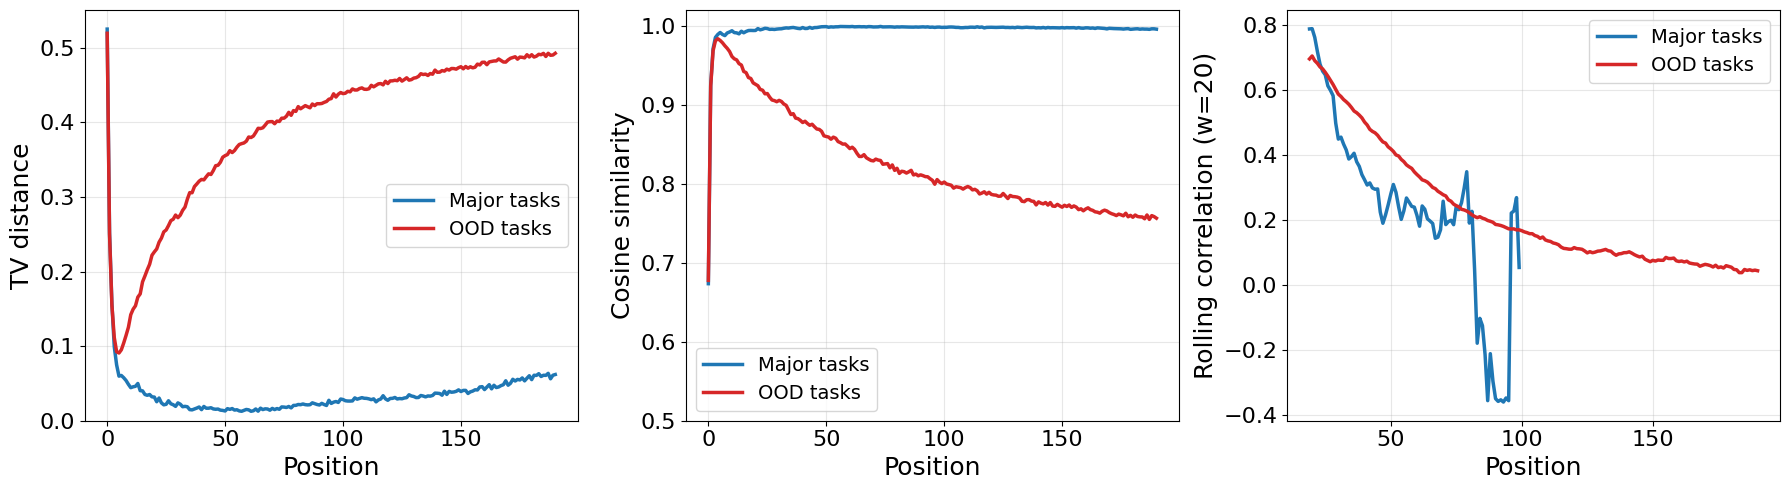

In [32]:
from icl.latent_markov.analysis import plot_lambda_posterior_agreement
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=-1)
out = plot_lambda_posterior_agreement(
    exp_name=exp_name,      # e.g. get_exp_name("latent", k)
    layer_index=3,          # None -> last layer
    n_ood=30,
    B=64,
    fit_n_samples=5000,
    fit_positions=list(range(1, 25)) + list(range(150, 180)),
    window=20,              # rolling correlation window
    figsize=(18, 5),
    title="",
    show=True,
)

# Returned keys include:
# out["tv_major"], out["tv_ood"], out["cos_major"], out["cos_ood"],
# out["rcorr_major"], out["rcorr_ood"], out["positions"]

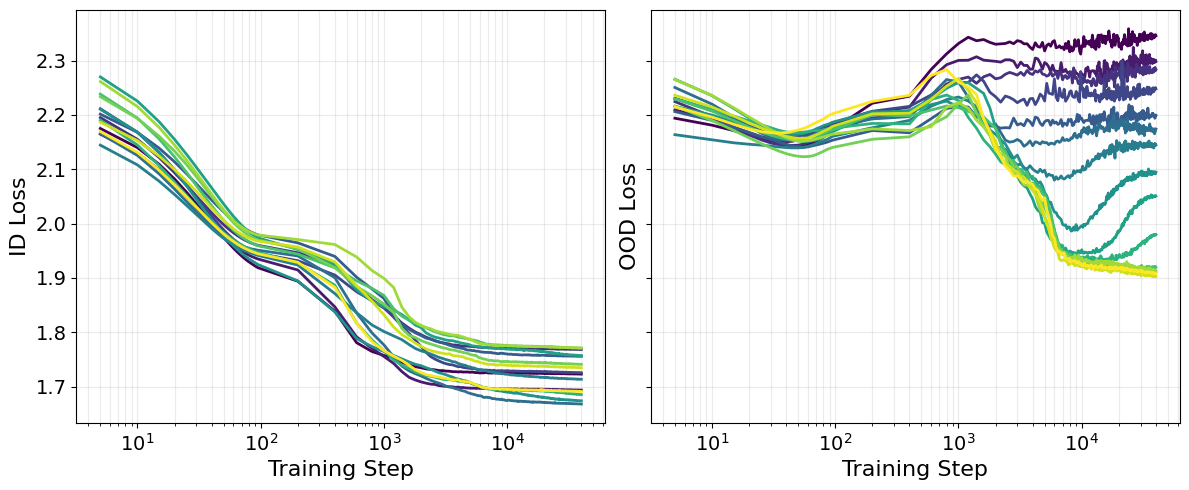

In [13]:
from icl.latent_markov.analysis import plot_id_ood_loss
out = plot_id_ood_loss(
    k_list=range(-1, 14),      # k where n_minor = 2**k (k=-1 means 0)
    logx=True,                 # log-scale x-axis
    figsize=(12, 5),
    show=True,
)

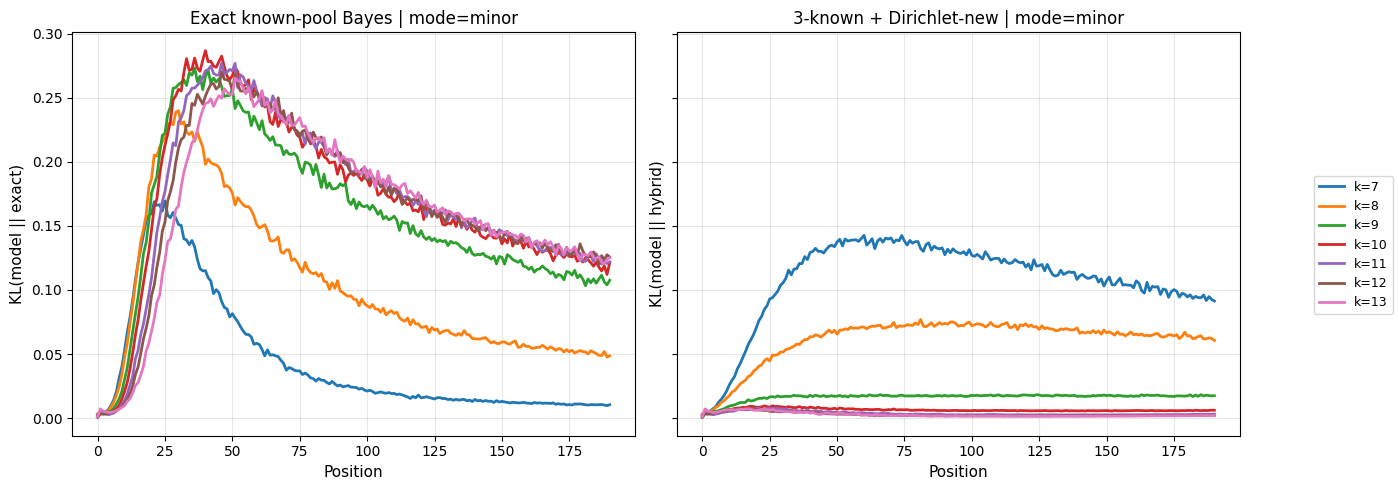

In [14]:
from icl.latent_markov.analysis.kl_divergence import plot_kl_model_vs_two_bayes_latent_across_k

out = plot_kl_model_vs_two_bayes_latent_across_k(
    k_values=range(7, 14),
    mode="minor",
    num_samples=1024,
    force_nonpadded=True,
    add_std_band=False,
    same_y_axis=True,
)

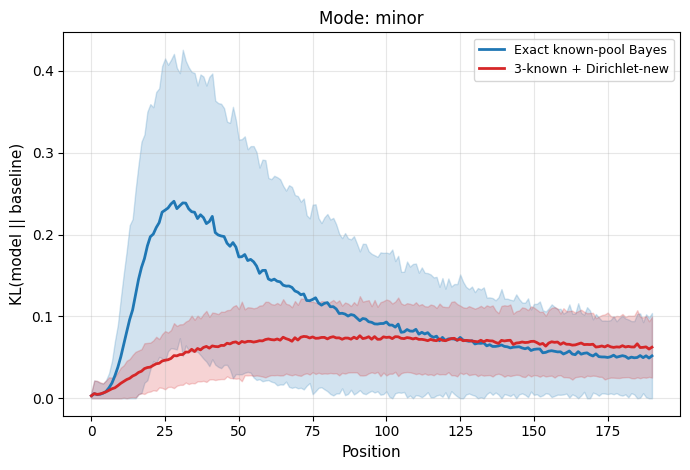

In [15]:
from icl.latent_markov.analysis.kl_divergence import plot_kl_model_vs_two_bayes_latent
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", 8)
out = plot_kl_model_vs_two_bayes_latent(
    exp_name=exp_name,
    modes="minor",
    num_samples=1024,
    force_nonpadded=True,
)

2026-03-02 03:20:31 - icl.latent_markov.analysis.directions - INFO - [task-subspace-r2-latent] center=True, rank=2, D=128, chance=0.0156


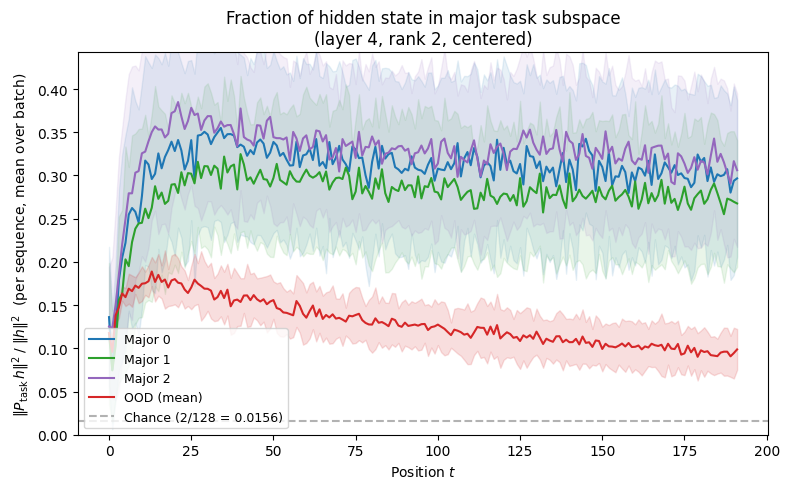

In [17]:
from icl.latent_markov.analysis import plot_task_subspace_r2_over_positions
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=-1)
res = plot_task_subspace_r2_over_positions(
    exp_name=exp_name,
    layer=4,
    n_ood=4,
    B=64,
)

2026-03-02 03:22:54 - icl.latent_markov.analysis.directions - INFO - [task-subspace-r2-latent] center=True, rank=2, D=128, chance=0.0156


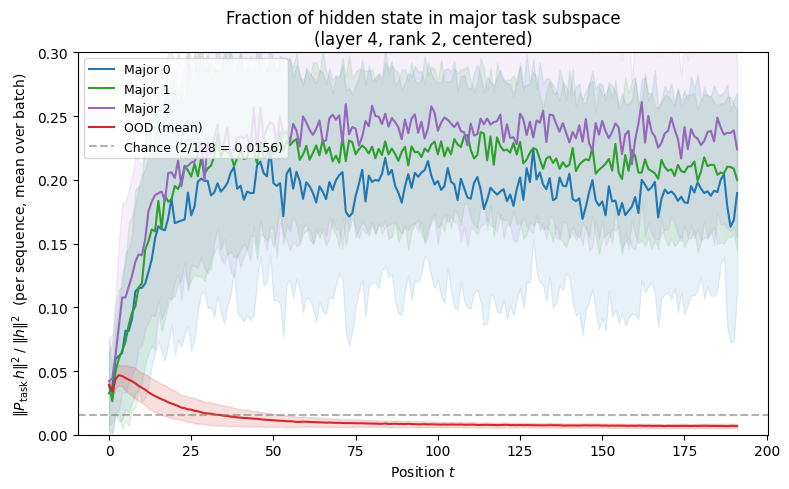

In [18]:
from icl.latent_markov.analysis import plot_task_subspace_r2_over_positions
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=11)
res = plot_task_subspace_r2_over_positions(
    exp_name=exp_name,
    layer=4,
    n_ood=128,
    B=64,
)

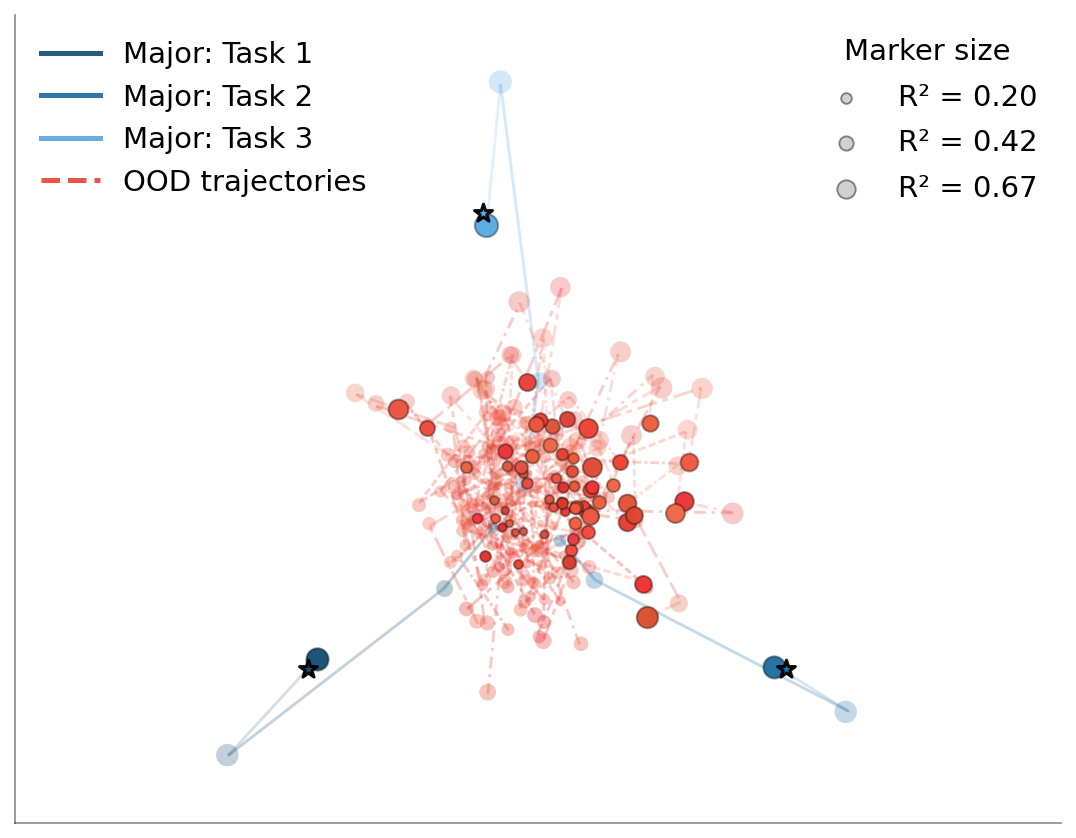

In [5]:
from icl.latent_markov.analysis import traj_posterior_projection_plot
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=-1)

out = traj_posterior_projection_plot(
    exp_name,
    layer_index=3,
    n_minor=0,
    n_ood=64,
    B=64,
    annotate=False,
)
# out['fig'], out['ax']: figure and axes
# out['lambdas'], out['r2_scores']: projection coefficients and fit quality
# out['final_task_vecs'], out['task_vecs_over_all_time']: vectors and trajectories

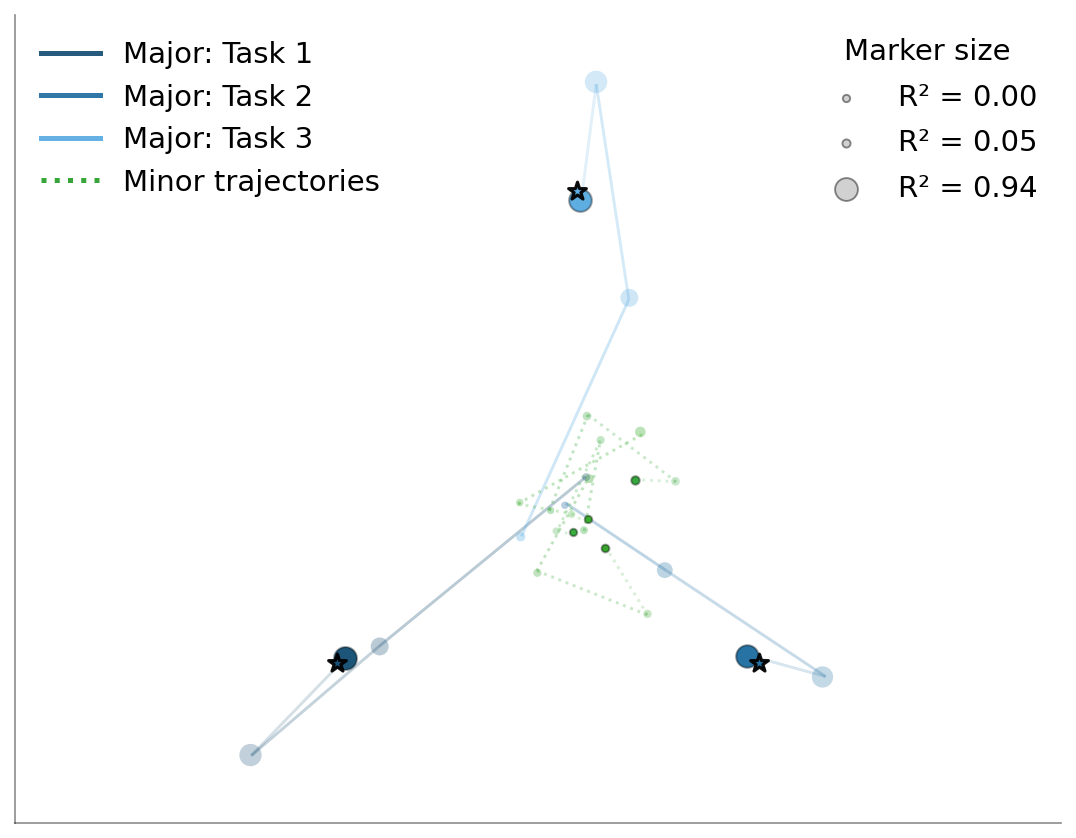

In [6]:
from icl.latent_markov.analysis import traj_posterior_projection_plot
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=2)

out = traj_posterior_projection_plot(
    exp_name,
    layer_index=3,
    n_minor=4,
    n_ood=0,
    B=64,
    annotate=False,
)
# out['fig'], out['ax']: figure and axes
# out['lambdas'], out['r2_scores']: projection coefficients and fit quality
# out['final_task_vecs'], out['task_vecs_over_all_time']: vectors and trajectories

2026-03-02 04:29:40 - icl.latent_markov.analysis.directions - INFO - [calc-dir-latent] Task subspace rank=2, D=128, chance fraction=0.0156, fit R2=0.7194


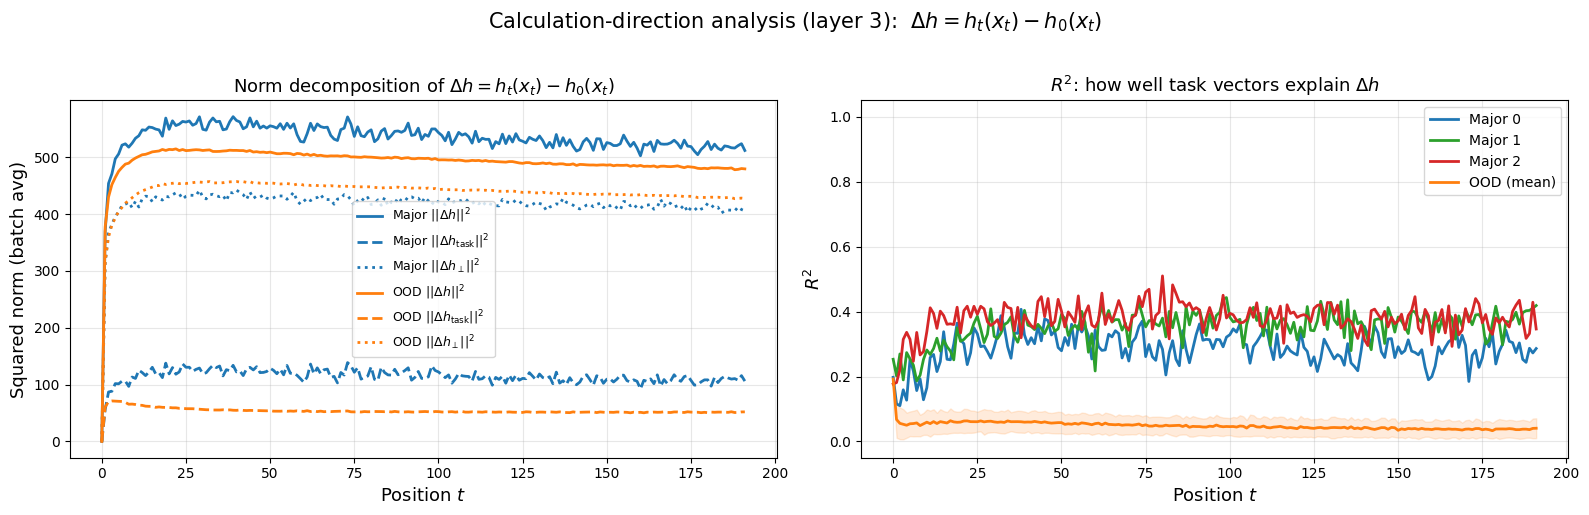

In [1]:
from icl.latent_markov.analysis import calculation_direction_analysis
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=11)
res = calculation_direction_analysis(
    exp_name=exp_name,
    layer_index=3,  # or None for last layer
    n_ood=128,
    B=64,
    center_task_vecs=True,
)

2026-03-02 04:40:04 - icl.latent_markov.analysis.interventions.ood_deltah - INFO - [ood-deltah-latent] Probe R2=0.7186, task subspace rank=3
2026-03-02 04:40:05 - icl.latent_markov.analysis.interventions.ood_deltah - INFO - [ood-deltah-latent] Protected subspace: task rank=3, token rank=3, total=6, mode=residual_pca
2026-03-02 04:40:06 - icl.latent_markov.analysis.interventions.ood_deltah - INFO - [ablation-latent] testing SVD component 0 ...
2026-03-02 04:40:08 - icl.latent_markov.analysis.interventions.ood_deltah - INFO - [ablation-latent] testing SVD component 1 ...
2026-03-02 04:40:11 - icl.latent_markov.analysis.interventions.ood_deltah - INFO - [ablation-latent] testing SVD component 2 ...
2026-03-02 04:40:14 - icl.latent_markov.analysis.interventions.ood_deltah - INFO - [ablation-latent] testing SVD component 3 ...
2026-03-02 04:40:16 - icl.latent_markov.analysis.interventions.ood_deltah - INFO - [ablation-latent] testing SVD component 4 ...
2026-03-02 04:40:19 - icl.latent_mark

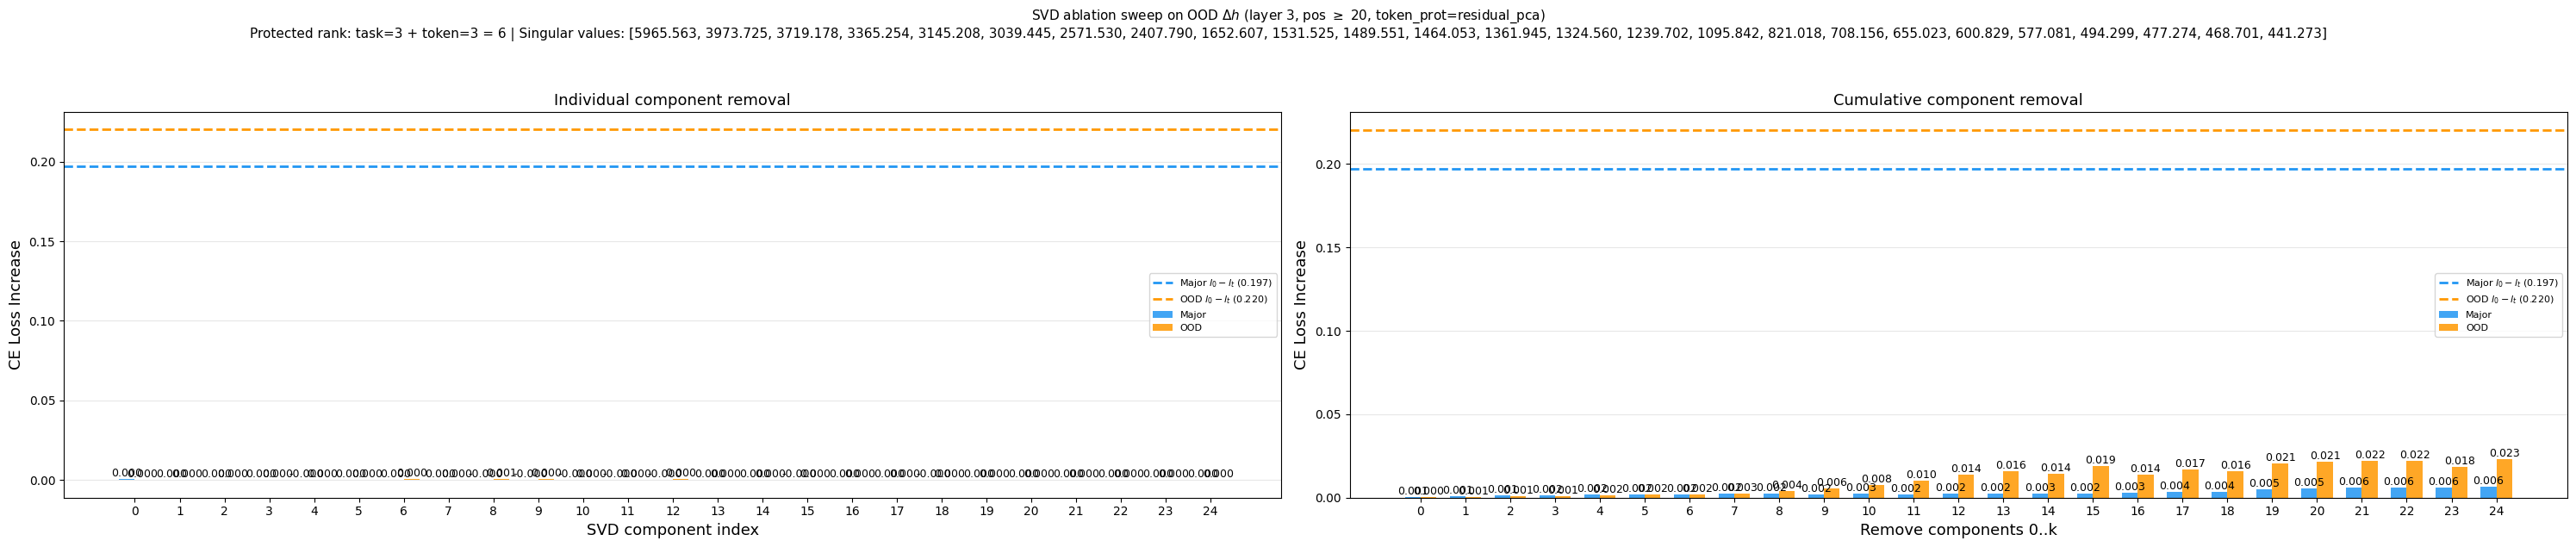


SVD Ablation Sweep — Latent (layer 3)
    k        SV   Δ Indiv Maj  Δ Indiv OOD   Δ Cumul Maj  Δ Cumul OOD
----------------------------------------------------------------------
    0  5965.563        0.0004       0.0002        0.0005       0.0003
    1  3973.725        0.0000       0.0001        0.0009       0.0005
    2  3719.178        0.0000       0.0001        0.0012       0.0007
    3  3365.254        0.0001       0.0000        0.0015       0.0010
    4  3145.208       -0.0000       0.0001        0.0017       0.0016
    5  3039.445        0.0000       0.0000        0.0017       0.0019
    6  2571.530        0.0001       0.0005        0.0021       0.0020
    7  2407.790        0.0001       0.0003        0.0023       0.0027
    8  1652.607       -0.0000       0.0008        0.0023       0.0040
    9  1531.525       -0.0000       0.0005        0.0020       0.0055
   10  1489.551       -0.0001       0.0004        0.0026       0.0076
   11  1464.053       -0.0000       0.0003        

In [3]:
from icl.latent_markov.analysis import intervene_remove_ood_deltah_subspace
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=11)

res = intervene_remove_ood_deltah_subspace(
    exp_name=exp_name,
    layer=3,
    ablation_max_k=25,
)

2026-03-02 18:36:19 - icl.latent_markov.analysis.interventions.optimal_orth - INFO - [opt-dir] Phase 1: Fitting probes ...
2026-03-02 18:36:30 - icl.latent_markov.analysis.interventions.optimal_orth - INFO - [opt-dir] Phase 2: Loading model & caching eval data ...
2026-03-02 18:36:34 - icl.latent_markov.analysis.interventions.optimal_orth - INFO - [opt-dir] Phase 3: Collecting hiddens + bigrams ...
2026-03-02 18:36:37 - icl.latent_markov.analysis.interventions.optimal_orth - INFO - [opt-dir] Layer 3 ...
2026-03-02 18:37:40 - icl.latent_markov.analysis.interventions.optimal_orth - INFO -   layer 3: d_maj=-0.0000 (-0.0%), d_ood=0.0927, d_minor=0.0929, R2(bi->V)=0.183
2026-03-02 18:37:40 - icl.latent_markov.analysis.interventions.optimal_orth - INFO - [opt-dir] Layer 4 ...
2026-03-02 18:38:43 - icl.latent_markov.analysis.interventions.optimal_orth - INFO -   layer 4: d_maj=0.0002 (0.0%), d_ood=0.0683, d_minor=0.0684, R2(bi->V)=0.715
2026-03-02 18:38:43 - icl.latent_markov.analysis.interve

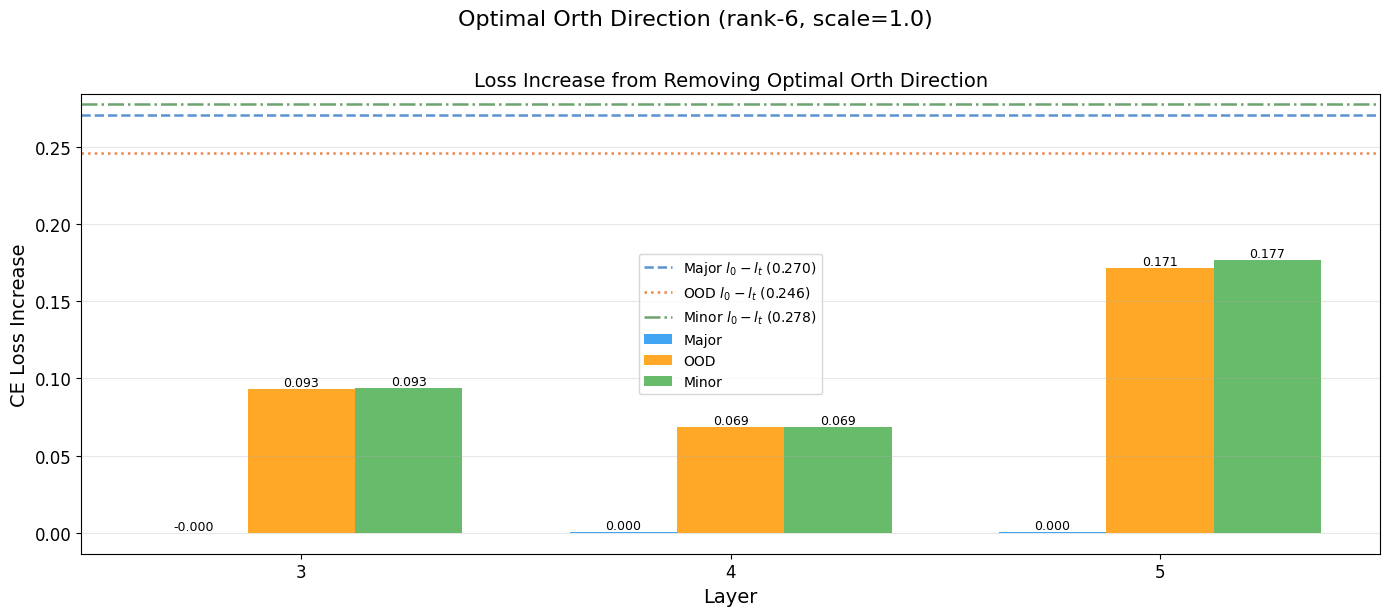

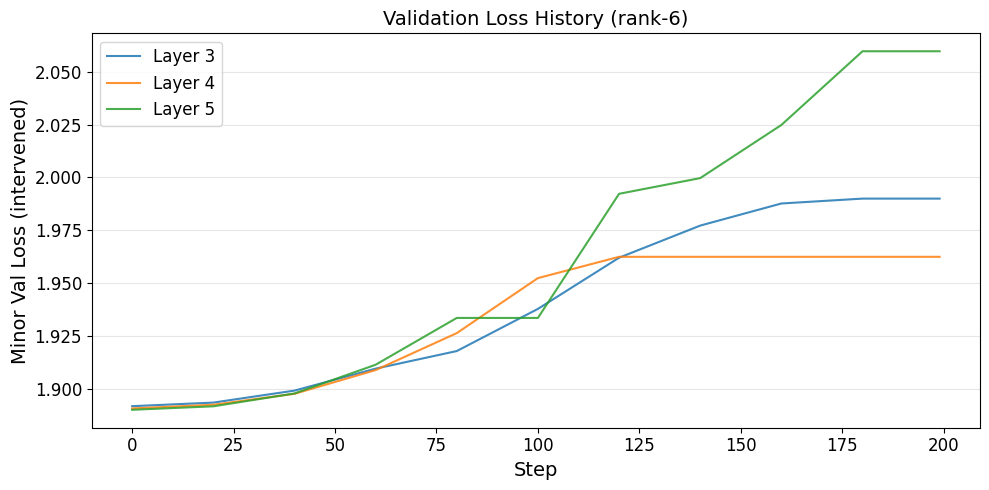

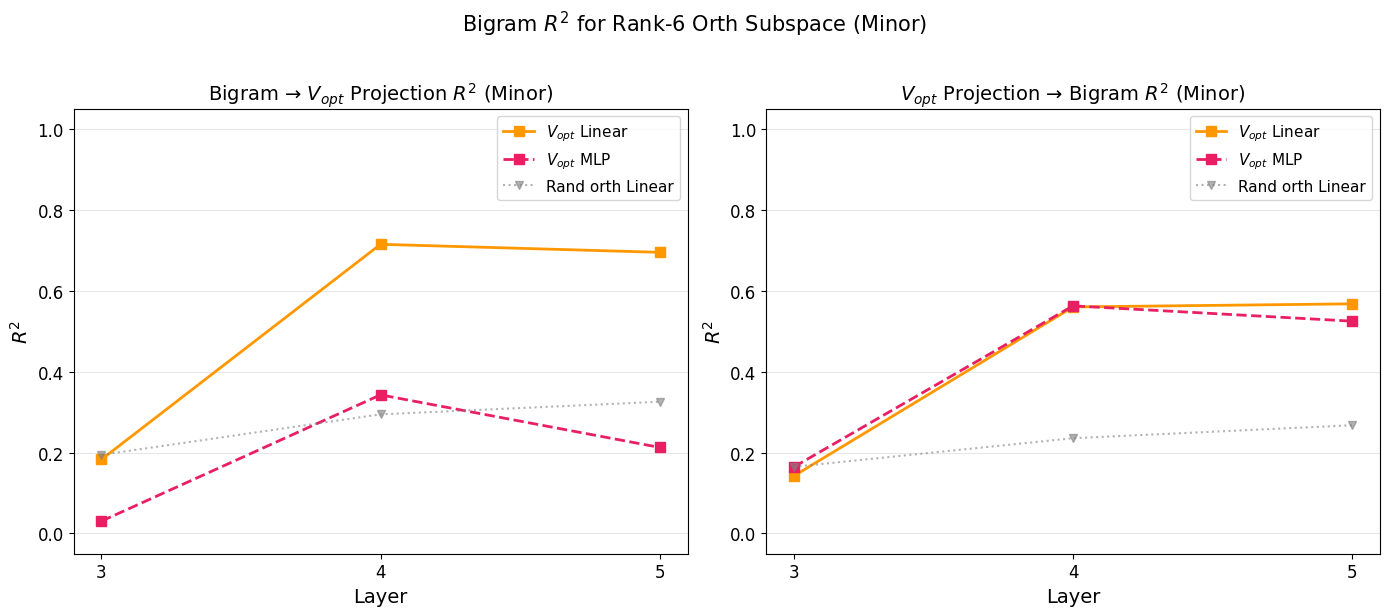

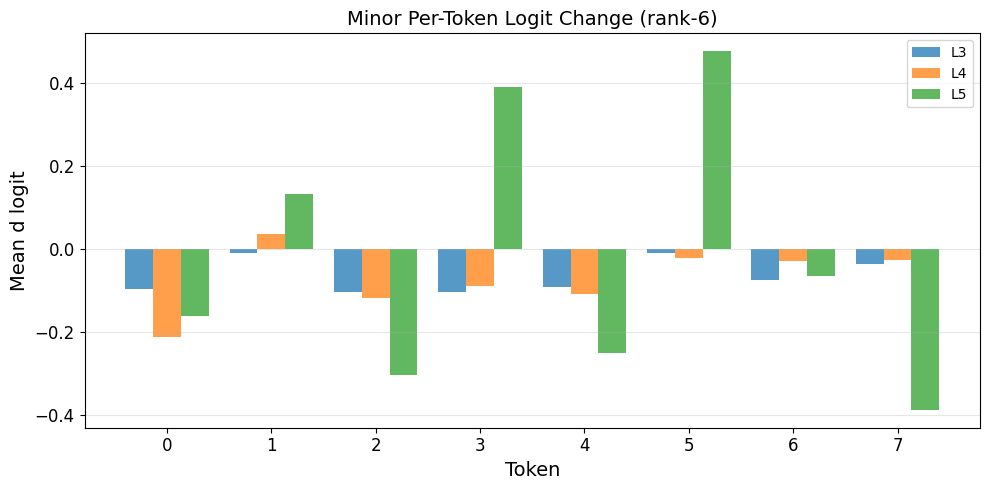

=== Major CE Loss Summary (V_opt removal) ===
  Layer 3: baseline=1.7209, d=-0.0001 (-0.0%)
  Layer 4: baseline=1.7209, d=0.0002 (0.0%)
  Layer 5: baseline=1.7209, d=0.0003 (0.0%)


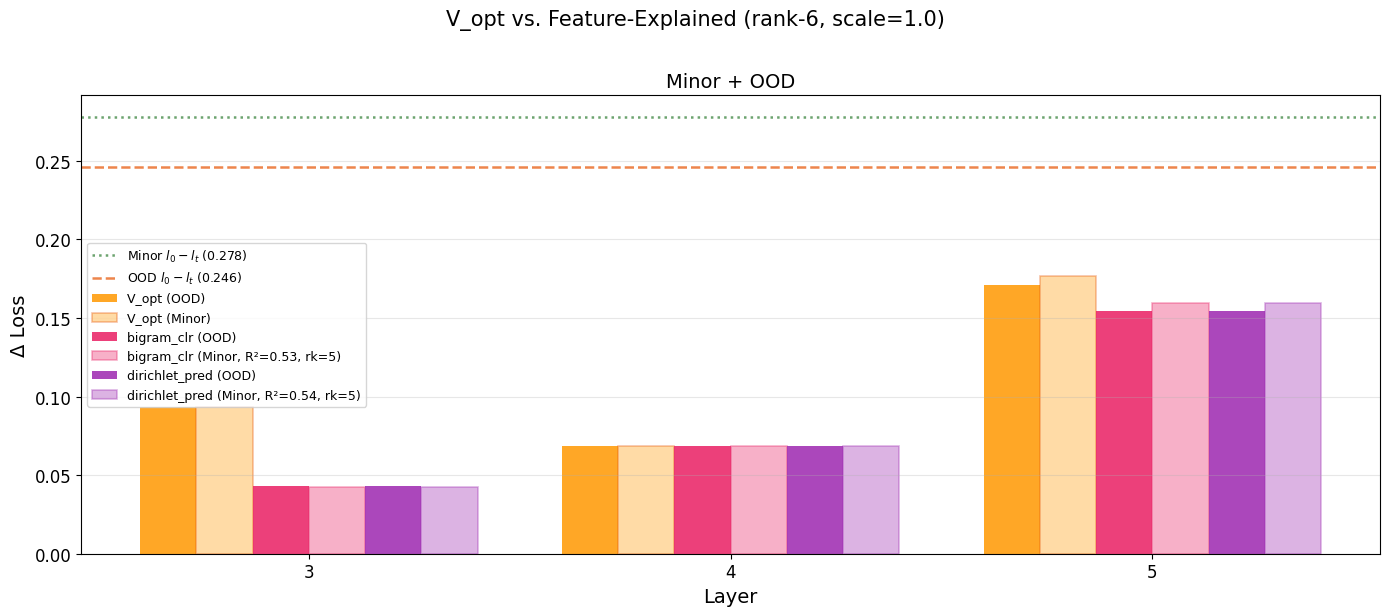

In [1]:
from icl.latent_markov.analysis import plot_optimal_orth_direction_across_layers
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=10)

fig_delta, fig_loss, fig_r2, fig_logit, fig_bigram, all_results = plot_optimal_orth_direction_across_layers(
    exp_name=exp_name,
    layers=range(3,6),
    n_directions=6,
    n_opt_steps=200,
    opt_lr=0.01,
    opt_B=64,
    patience=100,
    grad_clip_norm=1.0,
    n_samples_eval=2**11,
    n_samples_probe=2**10,
    n_ood=128,
    scale=1.0,
    opt_target="minor",
)

In [ ]:
from icl.latent_markov.analysis import intervene_remove_bigram_subspace, plot_remove_bigram_subspace_across_layers
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=11)

# Single layer, direct removal of bigram_clr subspace
res = intervene_remove_bigram_subspace(
    exp_name, 
    layer=5, feature_type="bigram_clr", method="direct",
)

2026-02-28 19:03:42 - icl.utils.latent_nonpadded - INFO - [bigram-removal] Protected subspace: task=3, token=3, total=6, orth_dim=122, mode=residual_pca
2026-02-28 19:03:44 - icl.utils.latent_nonpadded - INFO - [bigram-removal] bigram_clr regression R²=0.9470
2026-02-28 19:03:44 - icl.utils.latent_nonpadded - INFO - [bigram-removal] W_bigram rank=7, SVs: [0.26815569400787354, 0.26517558097839355, 0.2480412870645523, 0.2426367849111557, 0.2406637817621231, 0.2325805127620697, 0.22501026093959808]
2026-02-28 19:03:44 - icl.utils.latent_nonpadded - INFO - [bigram-removal] Direct removal: projecting out rank-7 bigram_clr subspace

Remove bigram_clr Subspace (direct) — Latent (layer 5)
  bigram_clr regression R² = 0.9470
  Feature subspace rank = 7
  Protected: task=3 + token=3 = 6

Metric                                Major          OOD
-------------------------------------------------------
Baseline CE                          1.7484       1.7614
Intervened CE                        1.74

2026-02-28 19:09:16 - icl.utils.latent_nonpadded - INFO - [bigram-removal sweep] layer 2 ...
2026-02-28 19:09:24 - icl.utils.latent_nonpadded - INFO - [bigram-removal] Protected subspace: task=3, token=0, total=3, orth_dim=125, mode=residual_pca
2026-02-28 19:09:26 - icl.utils.latent_nonpadded - INFO - [bigram-removal] dirichlet_pred regression R²=0.1467
2026-02-28 19:09:26 - icl.utils.latent_nonpadded - INFO - [bigram-removal] W_bigram rank=8, SVs: [0.15699109435081482, 0.09253976494073868, 0.07980494946241379, 0.0669483169913292, 0.06341511756181717, 0.059437934309244156, 0.044912055134773254, 0.035969555377960205]
2026-02-28 19:09:26 - icl.utils.latent_nonpadded - INFO - [bigram-removal] Direct removal: projecting out rank-8 dirichlet_pred subspace

Remove dirichlet_pred Subspace (direct) — Latent (layer 2)
  dirichlet_pred regression R² = 0.1467
  Feature subspace rank = 8
  Protected: task=3 + token=0 = 3

Metric                                Major          OOD
------------------

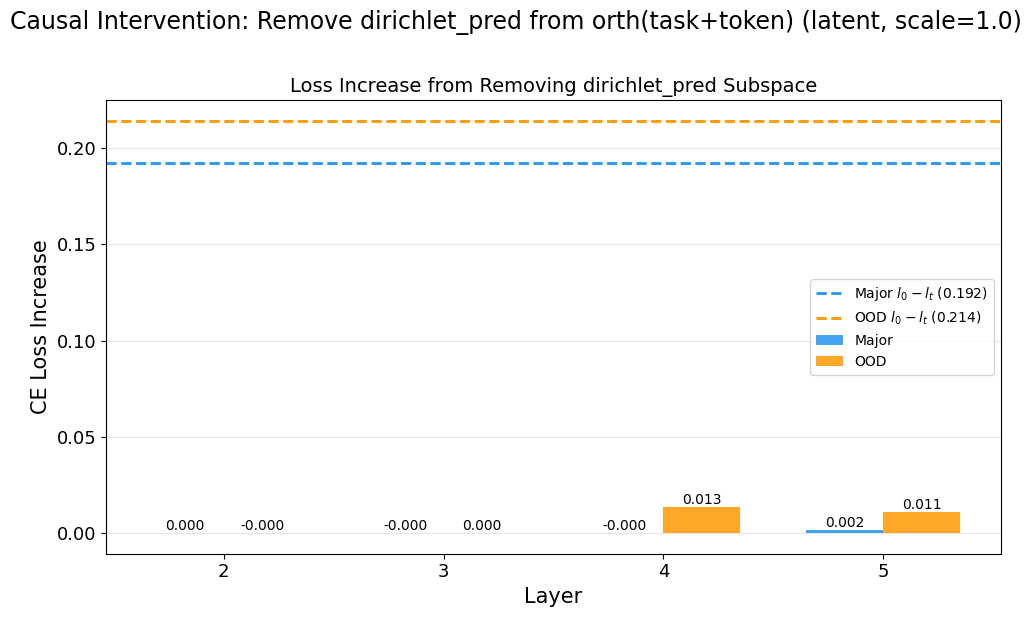

In [4]:
# Sweep across layers with barplot
fig, results = plot_remove_bigram_subspace_across_layers(
    exp_name, layers=[2,3,4,5],
    feature_type="dirichlet_pred",
    token_protection_rank=0,
)

2026-02-28 17:24:55 - icl.utils.latent_nonpadded - INFO - [remove-task plot] l_0 Major=1.9564, l_0 OOD=2.2039, gain Major=0.1883, gain OOD=0.1078


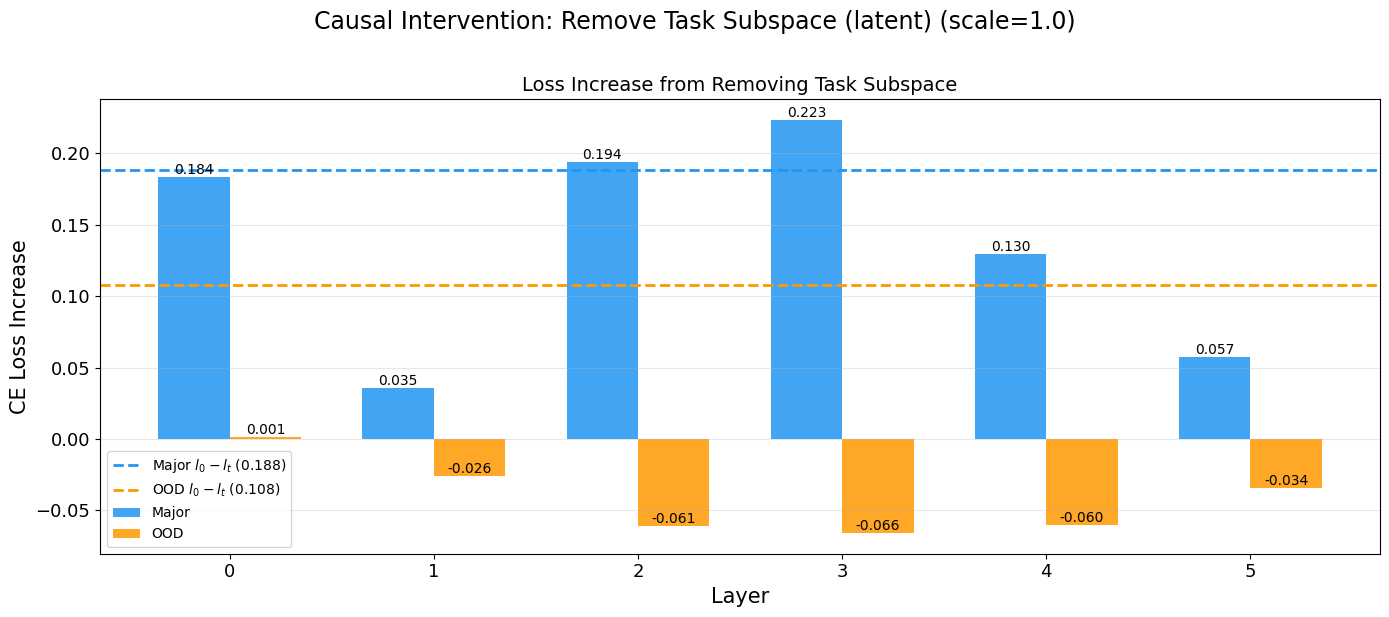

In [5]:
from icl.latent_markov.analysis import plot_intervention_remove_task_across_layers
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=11)
fig, all_results = plot_intervention_remove_task_across_layers(
    exp_name=exp_name,              
    layers=None,      # or None for all layers
    B=64,
    n_samples_eval=512,
    n_ood=128,
    fit_n_samples=2048,
    fit_positions=range(25),             # default late positions
    eval_positions=list(range(5, 25)),            # default all positions
    center_task_vecs=False,
    scale=1.0,
    figsize=(14, 6),
    show=True,
    save_path=None,
    verbose=False,
)

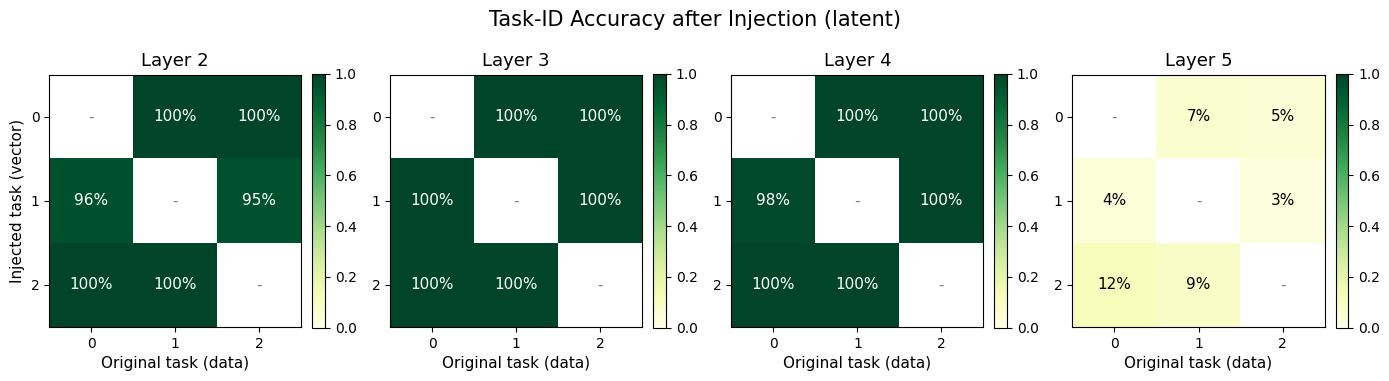

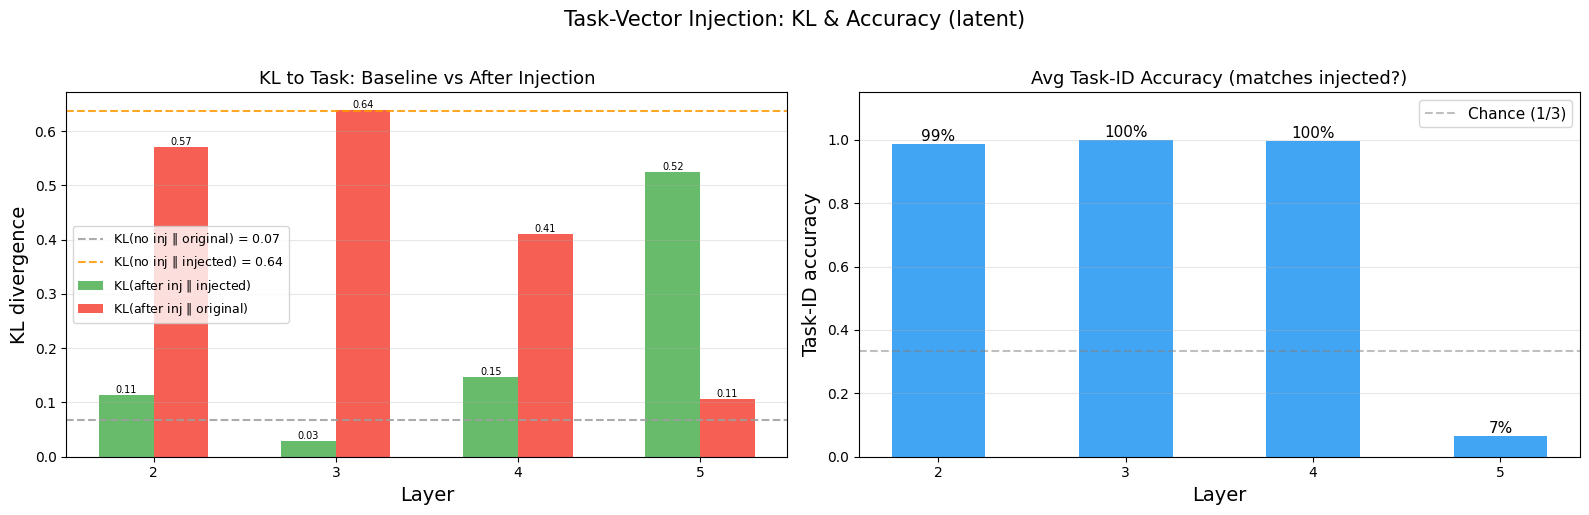

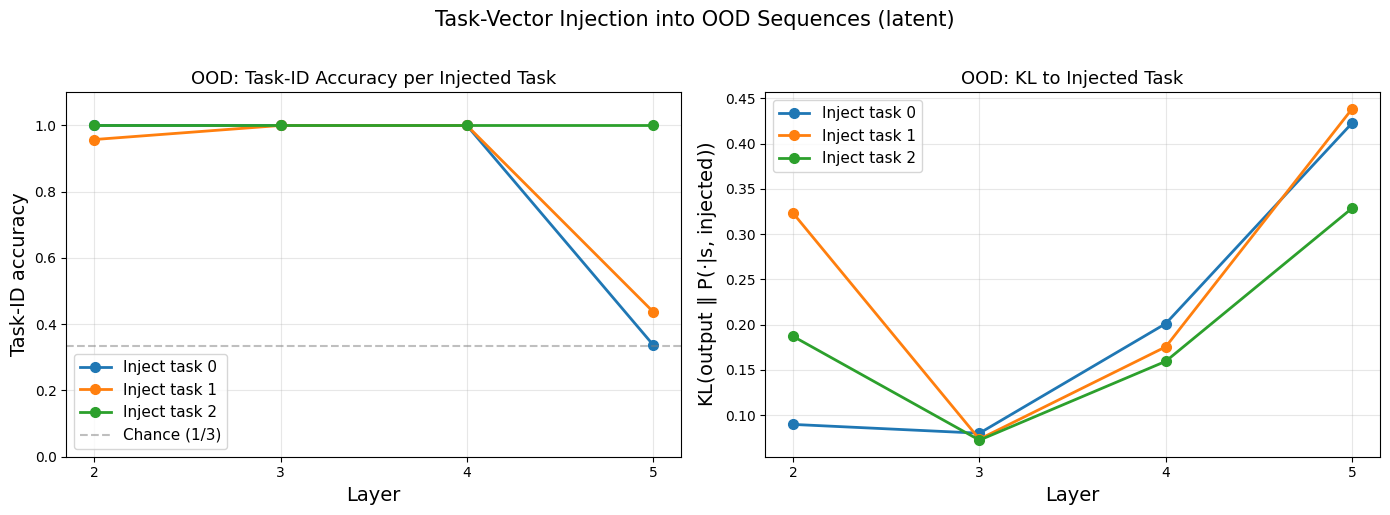

In [3]:
from icl.latent_markov.analysis import plot_inject_task_vector_across_layers
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=11)

fig_hm, fig_kl, fig_ood, all_results = plot_inject_task_vector_across_layers(
    exp_name=exp_name,
    layers=[2, 3, 4, 5],   # or None for all layers
    B=64,
    n_samples_eval=1024,
    n_ood=64,
    fit_n_samples=2**13,
    fit_positions=range(25),           
    eval_positions=range(25),          # defaults to all positions
    center_task_vecs=True,
    scale=1.0,
    show=True,
    verbose=False,
)

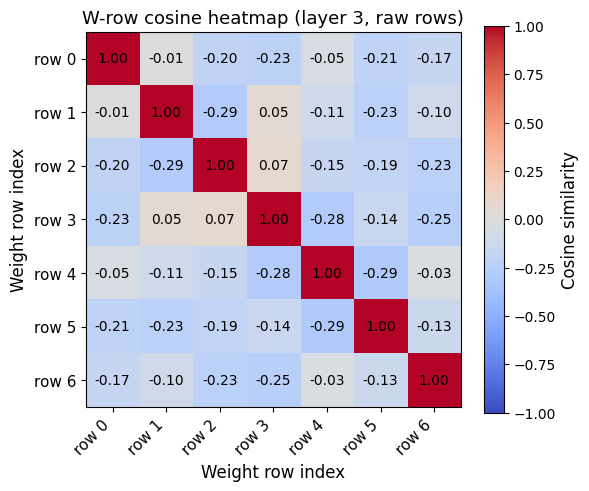

In [44]:
from icl.latent_markov.analysis import plot_weight_row_cosine_heatmap
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=2)

out = plot_weight_row_cosine_heatmap(
    exp_name=exp_name,
    layer_index=3,      # last layer
    fit_n_samples=2**12,
    sample_mode="train",   # to match 3-anchor task-vector setup
    n_minor=4,
    center_rows=False,      # matches traj_posterior_projection logic
    annotate=True,
    show=True,
)

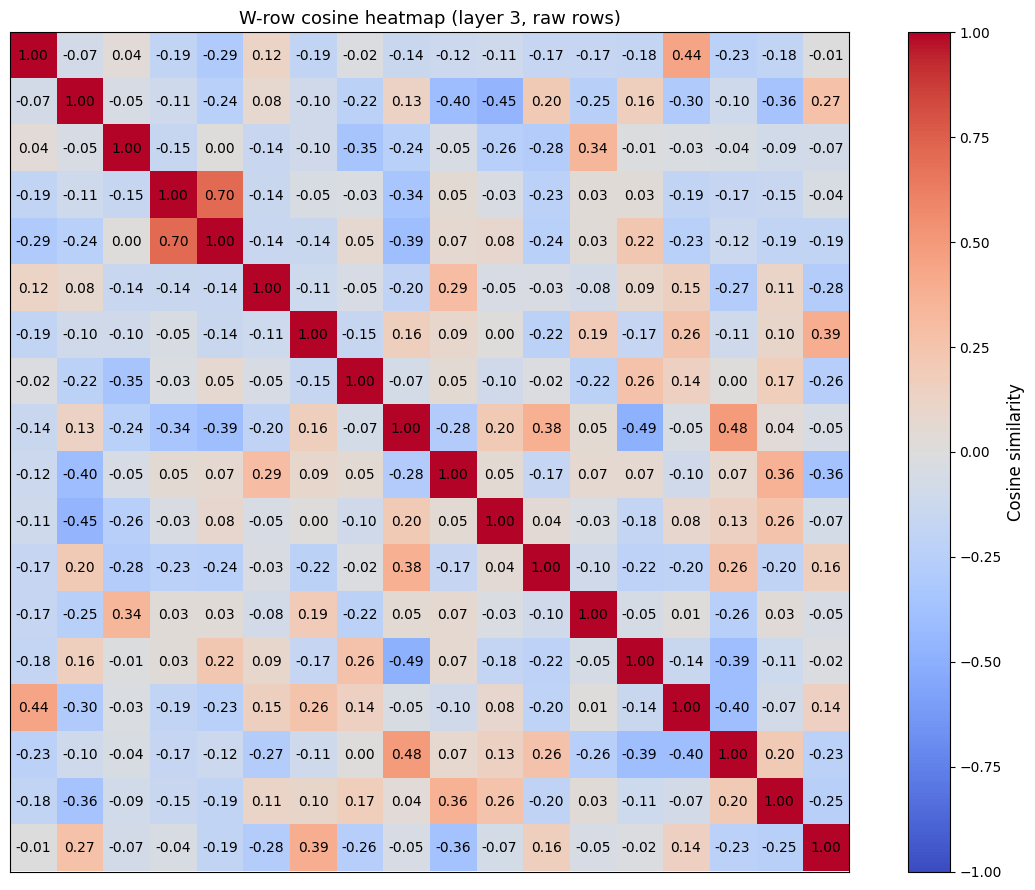

In [67]:
exp_name = get_exp_name("latent", k=8)

out = plot_weight_row_cosine_heatmap(
    exp_name=exp_name,
    layer_index=3,      # last layer
    fit_n_samples=2**12,
    sample_mode="train",   # to match 3-anchor task-vector setup
    n_minor=15,
    center_rows=False,      # matches traj_posterior_projection logic
    annotate=True,
    show_axes=False,
    show=True,
    figsize=(12, 9), 
)

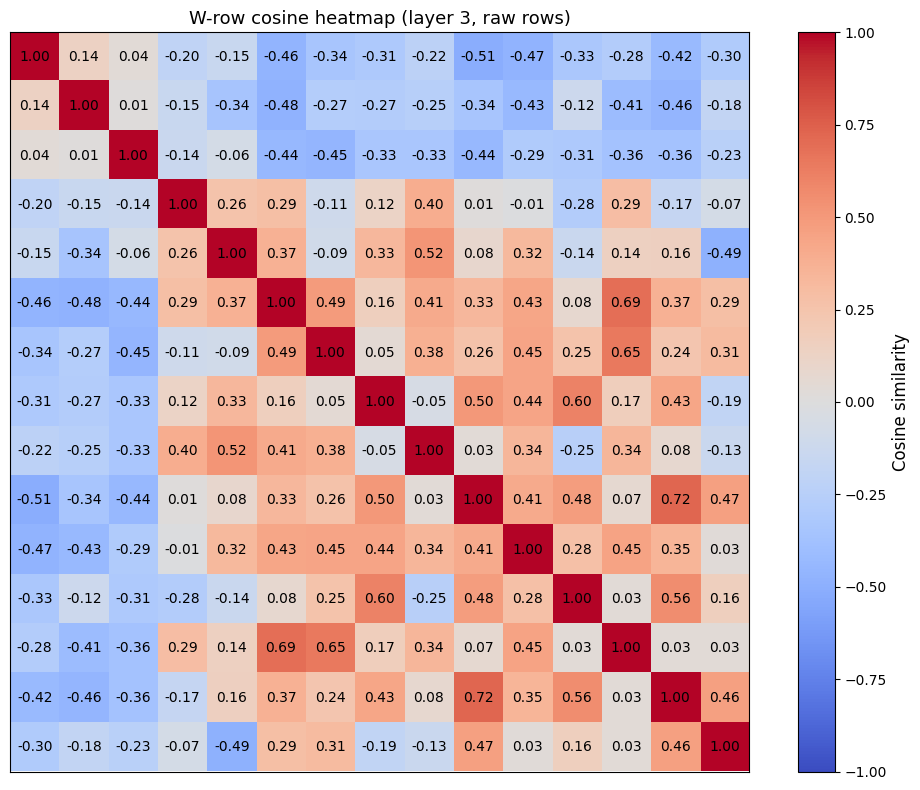

In [63]:
exp_name = get_exp_name("latent", k=10)

out = plot_weight_row_cosine_heatmap(
    exp_name=exp_name,
    layer_index=3,      # last layer
    fit_n_samples=2**12,
    sample_mode="train",   # to match 3-anchor task-vector setup
    n_minor=12,
    center_rows=False,      # matches traj_posterior_projection logic
    annotate=True,
    show_axes=False,
    show=True,
    figsize=(10, 8), 
)

In [50]:
from icl.latent_markov.analysis import compute_weight_row_orthogonality_metrics
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=2)
out = compute_weight_row_orthogonality_metrics(
    exp_name=exp_name,
    layer_index=3,
    fit_n_samples=2**12,
    sample_mode="train",
    n_minor=4,
    center_rows=False,   # recommended for strict orthogonality claim
    print_summary=True,
)

=== W-row Orthogonality Metrics (latent non-padded) ===
Layer: 3, n_rows: 7, centered: False
mean |offdiag cosine| : 0.162979
max  |offdiag cosine| : 0.290231
||G - I||_F           : 1.199454
||G - I||_F / K       : 0.171351
condition number      : 5.200008
effective rank        : 6.489442


In [56]:
from icl.latent_markov.analysis import compute_weight_row_orthogonality_metrics
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=4)
out = compute_weight_row_orthogonality_metrics(
    exp_name=exp_name,
    layer_index=3,
    fit_n_samples=2**12,
    sample_mode="train",
    n_minor=16,
    center_rows=False,   # recommended for strict orthogonality claim
    print_summary=True,
)

=== W-row Orthogonality Metrics (latent non-padded) ===
Layer: 3, n_rows: 19, centered: False
mean |offdiag cosine| : 0.141279
max  |offdiag cosine| : 0.545362
||G - I||_F           : 3.258888
||G - I||_F / K       : 0.171520
condition number      : 8.817326
effective rank        : 16.803013


In [52]:
from icl.latent_markov.analysis import compute_weight_row_orthogonality_metrics
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=6)
out = compute_weight_row_orthogonality_metrics(
    exp_name=exp_name,
    layer_index=3,
    fit_n_samples=2**12,
    sample_mode="train",
    n_minor=64,
    center_rows=False,   # recommended for strict orthogonality claim
    print_summary=True,
)

=== W-row Orthogonality Metrics (latent non-padded) ===
Layer: 3, n_rows: 67, centered: False
mean |offdiag cosine| : 0.155177
max  |offdiag cosine| : 0.669100
||G - I||_F           : 12.771146
||G - I||_F / K       : 0.190614
condition number      : 53.142095
effective rank        : 42.938400


In [54]:
from icl.latent_markov.analysis import compute_weight_row_orthogonality_metrics
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=8)
out = compute_weight_row_orthogonality_metrics(
    exp_name=exp_name,
    layer_index=3,
    fit_n_samples=2**12,
    sample_mode="train",
    n_minor=256,
    center_rows=False,   # recommended for strict orthogonality claim
    print_summary=True,
)

=== W-row Orthogonality Metrics (latent non-padded) ===
Layer: 3, n_rows: 259, centered: False
mean |offdiag cosine| : 0.167160
max  |offdiag cosine| : 0.809603
||G - I||_F           : 53.632870
||G - I||_F / K       : 0.207077
condition number      : 131.420861
effective rank        : 62.002243


In [55]:
from icl.latent_markov.analysis import compute_weight_row_orthogonality_metrics
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=10)
out = compute_weight_row_orthogonality_metrics(
    exp_name=exp_name,
    layer_index=3,
    fit_n_samples=2**12,
    sample_mode="train",
    n_minor=512,
    center_rows=False,   # recommended for strict orthogonality claim
    print_summary=True,
)

=== W-row Orthogonality Metrics (latent non-padded) ===
Layer: 3, n_rows: 515, centered: False
mean |offdiag cosine| : 0.267629
max  |offdiag cosine| : 1.000000
||G - I||_F           : 176.057526
||G - I||_F / K       : 0.341859
condition number      : 183.126657
effective rank        : 51.881050
